# Research Question: Which areas have the highest crime rates?

This notebook analyzes incident counts by area using `LOCATION_TEXT` from the cleaned dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Optional for cleaner default style
plt.style.use('seaborn-v0_8-whitegrid')

# Keep chart outputs scoped to this analysis to reduce merge conflicts
FIGURES_DIR = Path('../figures/highest_crime_areas')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
data_path = '../data/processed/tops_crime_data_cleaned.csv'
df = pd.read_csv(data_path)

print(f'Rows: {len(df):,}')
print('Columns:', list(df.columns))
df.head()

Rows: 163,722
Columns: ['CREATE_TIME_INCIDENT', 'DISPO_TEXT', 'LOCATION_TEXT', 'Latitude', 'Longitude']


,CREATE_TIME_INCIDENT,DISPO_TEXT,LOCATION_TEXT,Latitude,Longitude
0,2025-10-13 12:15:08,COMMUNITY POLICING,SAMMONS MEDIA,30.452343,-84.278508
1,2025-10-13 14:31:26,MISC SERVICE CALL,NaN,30.405325,-84.394920
2,2025-04-10 16:15:18,MISC SERVICE CALL,NaN,30.527557,-84.220477
3,2025-05-20 14:29:41,MISC SERVICE CALL,NaN,30.438515,-84.299572
4,2025-10-14 08:27:37,TRESPASSING,NaN,30.444864,-84.292854


In [4]:
# Use LOCATION_TEXT as area label; fill missing values for grouping
df['area'] = df['LOCATION_TEXT'].fillna('Unknown / Not Provided').replace('', 'Unknown / Not Provided')

area_counts = (
    df.groupby('area')
      .size()
      .reset_index(name='crime_count')
      .sort_values('crime_count', ascending=False)
)

# Cap counts at 1,000 for clearer plotting while preserving true counts
area_counts['crime_count_capped'] = area_counts['crime_count'].clip(upper=1000)

area_counts.head(10)

,area,crime_count,crime_count_capped
4436,Unknown / Not Provided,71746,1000
909,CIRCLE K,2703,1000
3369,PUBLIX SUPER MARKET,2023,1000
1234,DOLLAR GENERAL,1652,1000
4522,WAL-MART SUPERCENTER,1614,1000
4308,TPD,1488,1000
2454,LCSO,1427,1000
2483,LEON CO DETENTION FACILITY,1366,1000
4529,WALMART SUPERCENTER,1023,1000
4546,WAWA,803,803


In [5]:
# Wide-format summary using pivot_table (reshaping requirement)

# Create simple categorical groupings based on crime counts
area_counts['crime_level'] = pd.qcut(
    area_counts['crime_count'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

# Mark whether an area is in the global top 10 by incident count
area_counts['area_group'] = ['Top 10' if i < 10 else 'Other' for i in range(len(area_counts))]

pivot_summary = pd.pivot_table(
    area_counts,
    index='crime_level',        # rows: crime level category
    columns='area_group',       # columns: Top 10 vs Other areas
    values='crime_count',
    aggfunc='mean'              # average incidents per group
)

pivot_summary

/tmp/ipykernel_7119/3970310233.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_summary = pd.pivot_table(


area_group,Other,Top 10
crime_level,,
Low,1.315713,NaN
Medium,4.400179,NaN
High,47.626441,8584.5


In [6]:
# Long-format version of the pivot table using melt

pivot_long = pivot_summary.reset_index().melt(
    id_vars='crime_level',
    value_vars=pivot_summary.columns,
    var_name='area_group',
    value_name='mean_crime_count'
)

pivot_long.head()

,crime_level,area_group,mean_crime_count
0,Low,Other,1.315713
1,Medium,Other,4.400179
2,High,Other,47.626441
3,Low,Top 10,NaN
4,Medium,Top 10,NaN


The table above shows the areas with the largest number of recorded incidents.

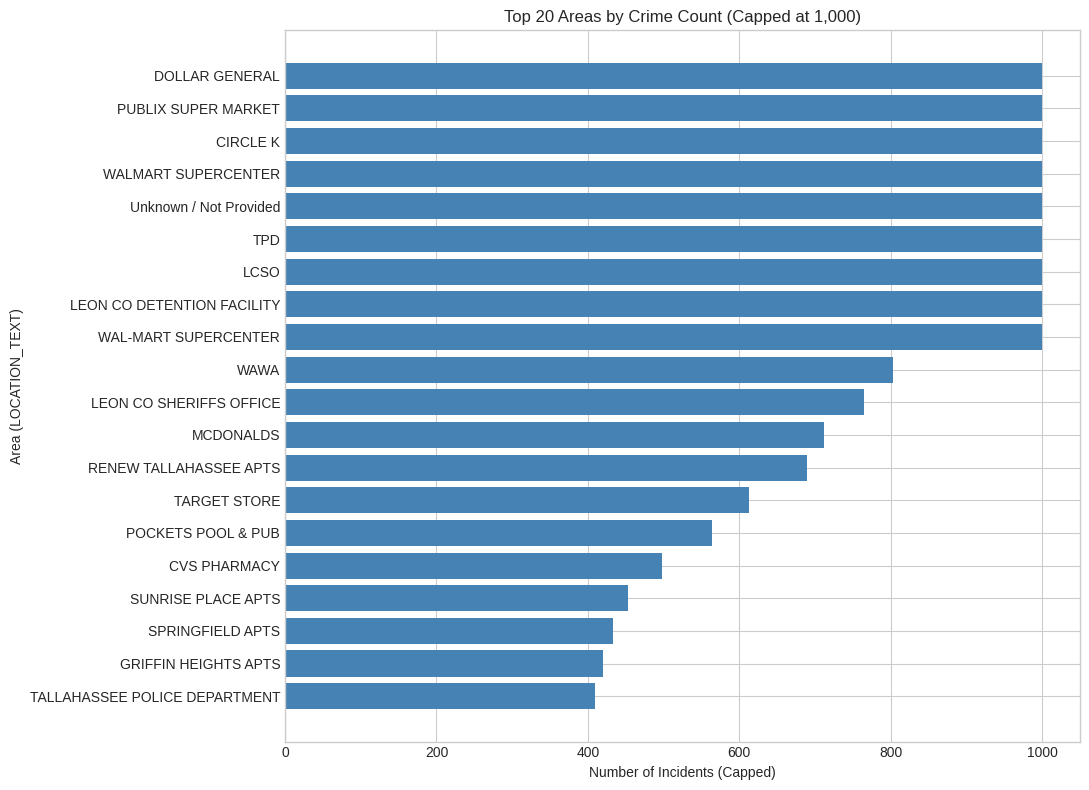

In [7]:
# Histogram-style comparison using top 20 areas by incident count (capped at 1,000)
top_n = 20
top_areas = area_counts.head(top_n).sort_values('crime_count_capped')

plt.figure(figsize=(11, 8))
plt.barh(top_areas['area'], top_areas['crime_count_capped'], color='steelblue')
plt.title(f'Top {top_n} Areas by Crime Count (Capped at 1,000)')
plt.xlabel('Number of Incidents (Capped)')
plt.ylabel('Area (LOCATION_TEXT)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'highest_crime_areas_top20_capped_1000.png', dpi=200)
plt.show()

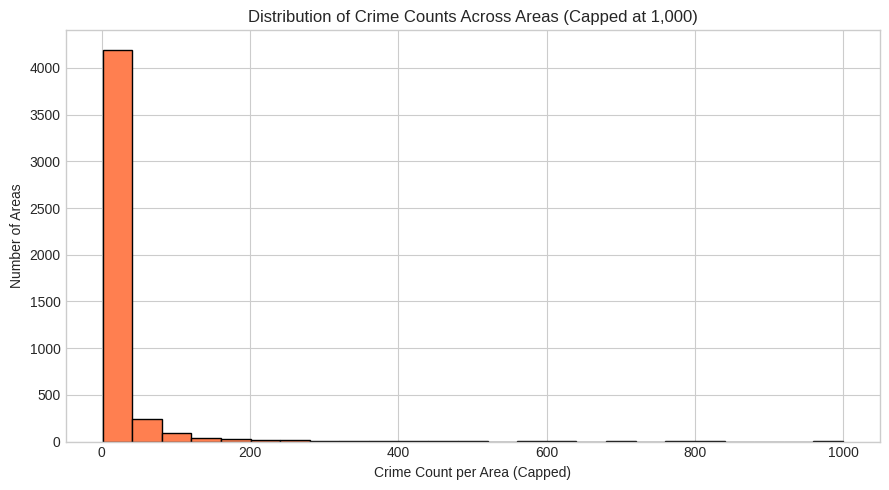

In [8]:
# Histogram of crime-count distribution across all areas (capped at 1,000)
plt.figure(figsize=(9, 5))
plt.hist(area_counts['crime_count_capped'], bins=25, color='coral', edgecolor='black')
plt.title('Distribution of Crime Counts Across Areas (Capped at 1,000)')
plt.xlabel('Crime Count per Area (Capped)')
plt.ylabel('Number of Areas')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'highest_crime_areas_distribution_capped_1000.png', dpi=200)
plt.show()

### Custom Feature: Crime Proportion

To provide a different perspective on crime concentration, I'm adding a `crime_proportion` feature. This feature calculates the percentage of the total number of incidents that occurred in each `LOCATION_TEXT` area.

In [10]:
# Calculate the total number of crimes across all areas
total_crimes = area_counts['crime_count'].sum()

# Calculate the proportion of crimes for each area
area_counts['crime_proportion'] = area_counts['crime_count'] / total_crimes

print(f"Total crimes recorded: {total_crimes:,}")
area_counts.head()

Total crimes recorded: 163,722


,area,crime_count,crime_count_capped,crime_level,area_group,crime_proportion
4436,Unknown / Not Provided,71746,1000,High,Top 10,0.438218
909,CIRCLE K,2703,1000,High,Top 10,0.016510
3369,PUBLIX SUPER MARKET,2023,1000,High,Top 10,0.012356
1234,DOLLAR GENERAL,1652,1000,High,Top 10,0.010090
4522,WAL-MART SUPERCENTER,1614,1000,High,Top 10,0.009858


### Findings

- A small number of areas account for much higher incident counts than most others.
- Counts are capped at 1,000 in the plots to improve readability and avoid one or two areas dominating the scale.
- The distribution remains right-skewed, indicating concentration of incidents in specific locations.
- Exported figures are saved to `../figures/highest_crime_areas/` to keep this branch's outputs isolated from teammates' analyses.